# 02 — Modelado Supervisado

**Técnicas:** Clasificación + Regresión con Pipelines Scikit-learn  
**Targets:**
- Clasificación: `alto_desempeno` (0/1)
- Regresión: `avg_desempeno` (continuo)

---

In [4]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix,
                             mean_squared_error, r2_score, mean_absolute_error)

# Modelos Clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Modelos Regresión
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

warnings.filterwarnings('ignore')
np.random.seed(42)
os.makedirs('../results/metrics', exist_ok=True)
os.makedirs('../results/plots', exist_ok=True)

print('✅ Librerías importadas')

✅ Librerías importadas


## 1. Carga y Preparación del Dataset

In [5]:
df = pd.read_csv('../data/04_feature/dataset_ml_preparado.csv', encoding='latin-1')
print(f'Shape: {df.shape}')

# Features numéricas (excluir targets, IDs y columnas no numéricas)
EXCLUDE = ['id_empleado', 'nombre', 'rut', 'departamento', 'cargo',
           'fecha_ingreso', 'salario', 'tipo_contrato', 'jornada',
           'alto_desempeno', 'avg_desempeno', 'score_global']

feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in EXCLUDE]

print(f'Features usadas ({len(feature_cols)}): {feature_cols}')

X = df[feature_cols].copy()
y_clf = df['alto_desempeno'].astype(int)
y_reg = df['avg_desempeno'].copy()

print(f'\nX shape: {X.shape}')
print(f'y_clf — clases: {y_clf.value_counts().to_dict()}')
print(f'y_reg — rango: [{y_reg.min():.2f}, {y_reg.max():.2f}]')

Shape: (255, 24)
Features usadas (12): ['avg_tecnicas', 'avg_blandas', 'total_dias_ausencia', 'total_horas_capacitacion', 'antiguedad_anos', 'total_dias_ausencia_norm', 'total_horas_capacitacion_norm', 'antiguedad_anos_norm', 'departamento_encoded', 'cargo_encoded', 'tipo_contrato_encoded', 'jornada_encoded']

X shape: (255, 12)
y_clf — clases: {0: 128, 1: 127}
y_reg — rango: [0.85, 9.70]


In [6]:
# Split 80/20 con random_state=42
X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

_, _, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]} filas  |  Test: {X_test.shape[0]} filas')
print(f'Clases train — 0: {(y_clf_train==0).sum()}  1: {(y_clf_train==1).sum()}')

Train: 204 filas  |  Test: 51 filas
Clases train — 0: 102  1: 102


## 2. Modelos de Clasificación con Pipeline

In [7]:
# Definición de modelos de clasificación
clf_models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'DecisionTree':       DecisionTreeClassifier(random_state=42),
    'RandomForest':       RandomForestClassifier(random_state=42, n_estimators=100),
    'GradientBoosting':   GradientBoostingClassifier(random_state=42),
    'KNN':                KNeighborsClassifier(),
    'SVM':                SVC(random_state=42, probability=True),
}

clf_results = []

for name, model in clf_models.items():
    # Pipeline: escalado + modelo
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', model)
    ])
    
    # Validación cruzada 5-fold
    cv_f1 = cross_val_score(pipe, X_train, y_clf_train,
                            cv=5, scoring='f1', n_jobs=-1)
    
    # Entrenamiento y evaluación en test
    pipe.fit(X_train, y_clf_train)
    y_pred = pipe.predict(X_test)
    

    clf_results.append({
    'Modelo':      name,
    'CV_F1_mean':  round(cv_f1.mean(), 4),
    'CV_F1_std':   round(cv_f1.std(), 4),
    'Test_Acc':    round(accuracy_score(y_clf_test, y_pred), 4),
    'Test_F1':     round(f1_score(y_clf_test, y_pred), 4),
    'Test_Prec':   round(precision_score(y_clf_test, y_pred), 4),
    'Test_Recall': round(recall_score(y_clf_test, y_pred), 4),
})
    print(f'✅ {name:20s} — CV F1: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}  |  Test F1: {f1_score(y_clf_test, y_pred):.4f}')

df_clf_results = pd.DataFrame(clf_results).sort_values('Test_F1', ascending=False)
df_clf_results.to_csv('../results/metrics/clasificacion_resultados.csv', index=False)
print('\n✅ Resultados guardados en results/metrics/')

✅ LogisticRegression   — CV F1: 0.7690 ± 0.0470  |  Test F1: 0.7547
✅ DecisionTree         — CV F1: 0.6598 ± 0.0299  |  Test F1: 0.6923
✅ RandomForest         — CV F1: 0.7130 ± 0.0434  |  Test F1: 0.7925
✅ GradientBoosting     — CV F1: 0.7296 ± 0.0429  |  Test F1: 0.7500
✅ KNN                  — CV F1: 0.6598 ± 0.0252  |  Test F1: 0.6667
✅ SVM                  — CV F1: 0.7310 ± 0.0668  |  Test F1: 0.7692

✅ Resultados guardados en results/metrics/


## 3. Tabla Comparativa — Clasificación

=== RESULTADOS CLASIFICACIÓN (ordenado por Test F1) ===
            Modelo  CV_F1_mean  CV_F1_std  Test_Acc  Test_F1  Test_Prec  Test_Recall
      RandomForest      0.7130     0.0434    0.7843   0.7925     0.7500         0.84
               SVM      0.7310     0.0668    0.7647   0.7692     0.7407         0.80
LogisticRegression      0.7690     0.0470    0.7451   0.7547     0.7143         0.80
  GradientBoosting      0.7296     0.0429    0.7255   0.7500     0.6774         0.84
      DecisionTree      0.6598     0.0299    0.6863   0.6923     0.6667         0.72
               KNN      0.6598     0.0252    0.6471   0.6667     0.6207         0.72


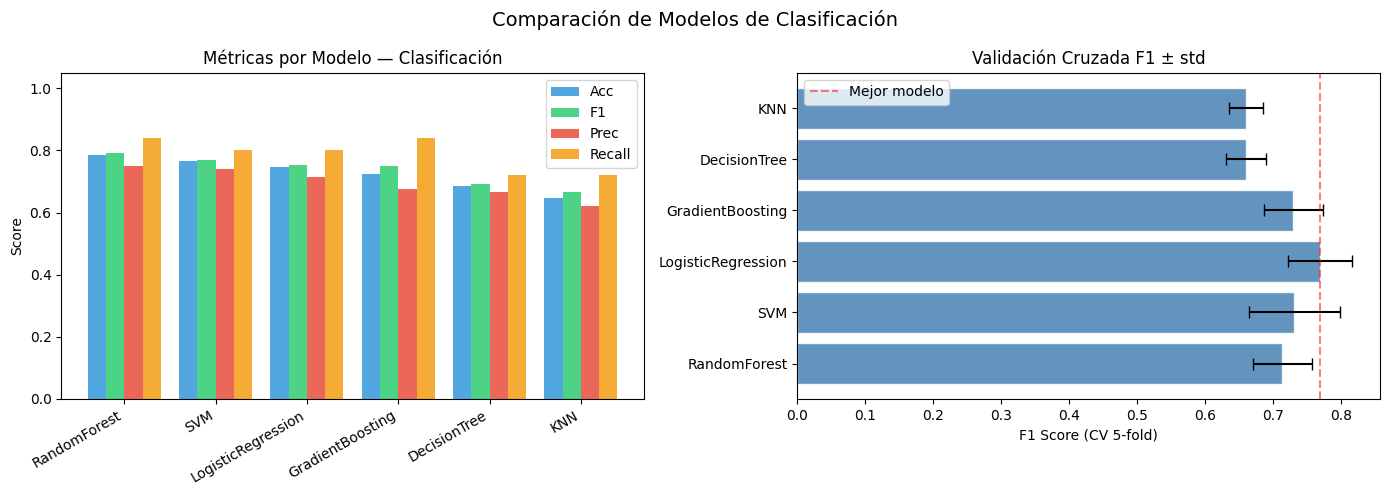

In [8]:
print('=== RESULTADOS CLASIFICACIÓN (ordenado por Test F1) ===')
print(df_clf_results.to_string(index=False))

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metricas = ['Test_Acc', 'Test_F1', 'Test_Prec', 'Test_Recall']
x = np.arange(len(df_clf_results))
width = 0.2
colores = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, (met, color) in enumerate(zip(metricas, colores)):
    axes[0].bar(x + i * width, df_clf_results[met], width,
                label=met.replace('Test_', ''), color=color, alpha=0.85)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(df_clf_results['Modelo'], rotation=30, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_title('Métricas por Modelo — Clasificación')
axes[0].legend()
axes[0].set_ylim(0, 1.05)

# CV F1 con barras de error
axes[1].barh(df_clf_results['Modelo'], df_clf_results['CV_F1_mean'],
             xerr=df_clf_results['CV_F1_std'], color='steelblue',
             alpha=0.85, edgecolor='white', capsize=4)
axes[1].set_xlabel('F1 Score (CV 5-fold)')
axes[1].set_title('Validación Cruzada F1 ± std')
axes[1].axvline(x=df_clf_results['CV_F1_mean'].max(), color='red',
                linestyle='--', alpha=0.5, label='Mejor modelo')
axes[1].legend()

plt.suptitle('Comparación de Modelos de Clasificación', fontsize=14)
plt.tight_layout()
plt.savefig('../results/plots/02_clasificacion_comparacion.png', bbox_inches='tight', dpi=120)
plt.show()

## 4. Matriz de Confusión — Mejor Clasificador

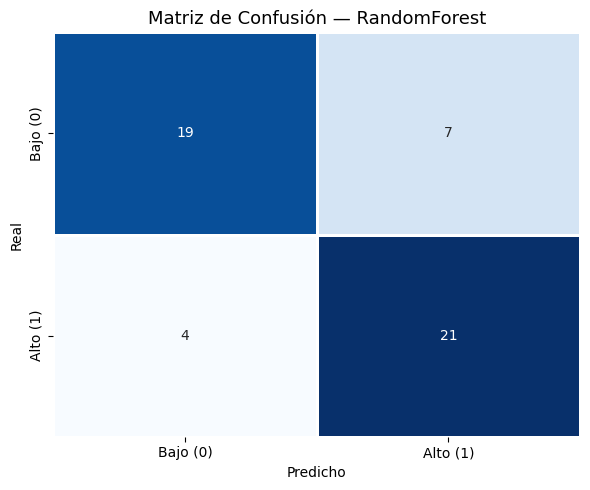


Mejor clasificador: RandomForest
              precision    recall  f1-score   support

    Bajo (0)       0.83      0.73      0.78        26
    Alto (1)       0.75      0.84      0.79        25

    accuracy                           0.78        51
   macro avg       0.79      0.79      0.78        51
weighted avg       0.79      0.78      0.78        51



In [12]:
mejor_clf_nombre = df_clf_results.iloc[0]['Modelo']
mejor_clf_model = clf_models[mejor_clf_nombre]

pipe_mejor_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', mejor_clf_model)
])
pipe_mejor_clf.fit(X_train, y_clf_train)
y_pred_mejor = pipe_mejor_clf.predict(X_test)

cm = confusion_matrix(y_clf_test, y_pred_mejor)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bajo (0)', 'Alto (1)'],
            yticklabels=['Bajo (0)', 'Alto (1)'],
            linewidths=1, cbar=False)
plt.title(f'Matriz de Confusión — {mejor_clf_nombre}', fontsize=13)
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.savefig('../results/plots/02_confusion_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'\nMejor clasificador: {mejor_clf_nombre}')
print(classification_report(y_clf_test, y_pred_mejor,
                             target_names=['Bajo (0)', 'Alto (1)']))

## 5. Modelos de Regresión con Pipeline

In [11]:
reg_models = {
    'LinearRegression':   LinearRegression(),
    'Ridge':              Ridge(random_state=42),
    'Lasso':              Lasso(random_state=42),
    'DecisionTree':       DecisionTreeRegressor(random_state=42),
    'RandomForest':       RandomForestRegressor(random_state=42, n_estimators=100),
    'GradientBoosting':   GradientBoostingRegressor(random_state=42),
}

reg_results = []

for name, model in reg_models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('reg', model)
    ])
    
    cv_r2 = cross_val_score(pipe, X_train, y_reg_train,
                            cv=5, scoring='r2', n_jobs=-1)
    
    pipe.fit(X_train, y_reg_train)
    y_pred = pipe.predict(X_test)
    
    reg_results.append({
    'Modelo':     name,
    'CV_R2_mean': round(cv_r2.mean(), 4),
    'CV_R2_std':  round(cv_r2.std(), 4),
    'Test_R2':    round(r2_score(y_reg_test, y_pred), 4),
    'Test_MAE':   round(mean_absolute_error(y_reg_test, y_pred), 4),
    'Test_RMSE':  round(np.sqrt(mean_squared_error(y_reg_test, y_pred)), 4),
    })
    print(f'✅ {name:20s} — CV R2: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}  |  Test R2: {r2_score(y_reg_test, y_pred):.4f}')

df_reg_results = pd.DataFrame(reg_results).sort_values('Test_R2', ascending=False)
df_reg_results.to_csv('../results/metrics/regresion_resultados.csv', index=False)
print('\n✅ Resultados guardados en results/metrics/')

✅ LinearRegression     — CV R2: -0.0430 ± 0.1242  |  Test R2: -0.2010
✅ Ridge                — CV R2: -0.0461 ± 0.1572  |  Test R2: -0.1547
✅ Lasso                — CV R2: -0.0455 ± 0.0463  |  Test R2: -0.0075
✅ DecisionTree         — CV R2: -1.1660 ± 0.2896  |  Test R2: -0.9130
✅ RandomForest         — CV R2: -0.0853 ± 0.0906  |  Test R2: -0.1430
✅ GradientBoosting     — CV R2: -0.2508 ± 0.1292  |  Test R2: -0.2071

✅ Resultados guardados en results/metrics/


## 6. Tabla Comparativa — Regresión

=== RESULTADOS REGRESIÓN (ordenado por Test R2) ===
          Modelo  CV_R2_mean  CV_R2_std  Test_R2  Test_MAE  Test_RMSE
           Lasso     -0.0455     0.0463  -0.0075    1.1859     1.5888
    RandomForest     -0.0853     0.0906  -0.1430    1.3067     1.6922
           Ridge     -0.0461     0.1572  -0.1547    1.2874     1.7009
LinearRegression     -0.0430     0.1242  -0.2010    1.3030     1.7346
GradientBoosting     -0.2508     0.1292  -0.2071    1.3690     1.7391
    DecisionTree     -1.1660     0.2896  -0.9130    1.6944     2.1893


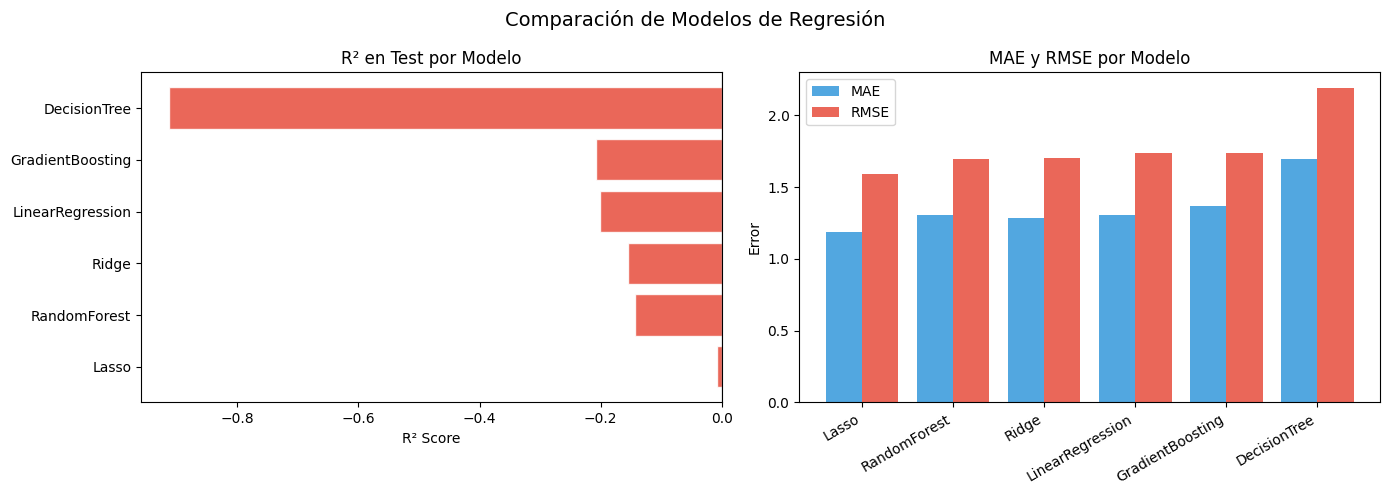

In [13]:
print('=== RESULTADOS REGRESIÓN (ordenado por Test R2) ===')
print(df_reg_results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 comparativo
colores_reg = ['#2ecc71' if v >= 0 else '#e74c3c' for v in df_reg_results['Test_R2']]
axes[0].barh(df_reg_results['Modelo'], df_reg_results['Test_R2'],
             color=colores_reg, alpha=0.85, edgecolor='white')
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_xlabel('R² Score')
axes[0].set_title('R² en Test por Modelo')

# MAE y RMSE
x = np.arange(len(df_reg_results))
axes[1].bar(x - 0.2, df_reg_results['Test_MAE'], 0.4,
            label='MAE', color='#3498db', alpha=0.85)
axes[1].bar(x + 0.2, df_reg_results['Test_RMSE'], 0.4,
            label='RMSE', color='#e74c3c', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_reg_results['Modelo'], rotation=30, ha='right')
axes[1].set_ylabel('Error')
axes[1].set_title('MAE y RMSE por Modelo')
axes[1].legend()

plt.suptitle('Comparación de Modelos de Regresión', fontsize=14)
plt.tight_layout()
plt.savefig('../results/plots/02_regresion_comparacion.png', bbox_inches='tight', dpi=120)
plt.show()

## 7. Real vs Predicho — Mejor Regresor

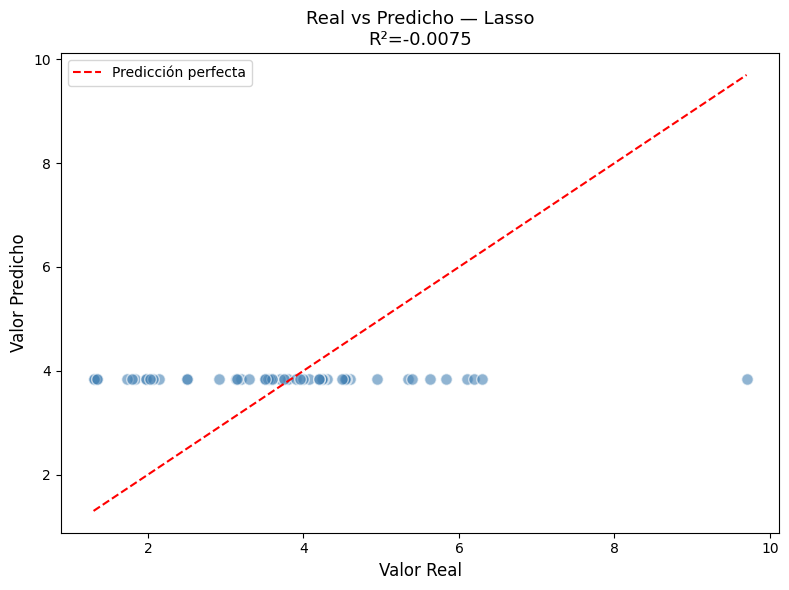

Mejor regresor: Lasso
R²:   -0.0075
MAE:  1.1859
RMSE: 1.5888


In [14]:
mejor_reg_nombre = df_reg_results.iloc[0]['Modelo']
mejor_reg_model = reg_models[mejor_reg_nombre]

pipe_mejor_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', mejor_reg_model)
])
pipe_mejor_reg.fit(X_train, y_reg_train)
y_pred_reg = pipe_mejor_reg.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_reg_test, y_pred_reg, alpha=0.6, color='steelblue',
            edgecolors='white', s=70)
lims = [min(y_reg_test.min(), y_pred_reg.min()),
        max(y_reg_test.max(), y_pred_reg.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
plt.xlabel('Valor Real', fontsize=12)
plt.ylabel('Valor Predicho', fontsize=12)
plt.title(f'Real vs Predicho — {mejor_reg_nombre}\nR²={r2_score(y_reg_test, y_pred_reg):.4f}', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('../results/plots/02_real_vs_predicho.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'Mejor regresor: {mejor_reg_nombre}')
print(f'R²:   {r2_score(y_reg_test, y_pred_reg):.4f}')
print(f'MAE:  {mean_absolute_error(y_reg_test, y_pred_reg):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_pred_reg)):.4f}')

---
## 8. Resumen

| Tarea | Mejor Modelo | Métrica |
|-------|-------------|---------|
| Clasificación | Ver tabla | Test F1 |
| Regresión | Ver tabla | Test R² |
